In [ ]:
import analysis as als
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

# adjust data path to directory were csv files are saved
data_path = '...'

# Block 1 Data

**Dependent variable:** Absolute difference in house prices with boxcox-transformation and scaled and centered (boxcox_gap_house_price_scaled)

In [2]:
data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p0', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

### Run the models + check assumptions

In [3]:
dependent = 'boxcox_gap_house_price_scaled'
save_plots = False


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8884                       
Min. group size:                    15                      Log-Likelihood:                     -6289.7693                   
Max. group size:                    20                      Converged:                          Yes                          
Mean group size:                    19.1                        

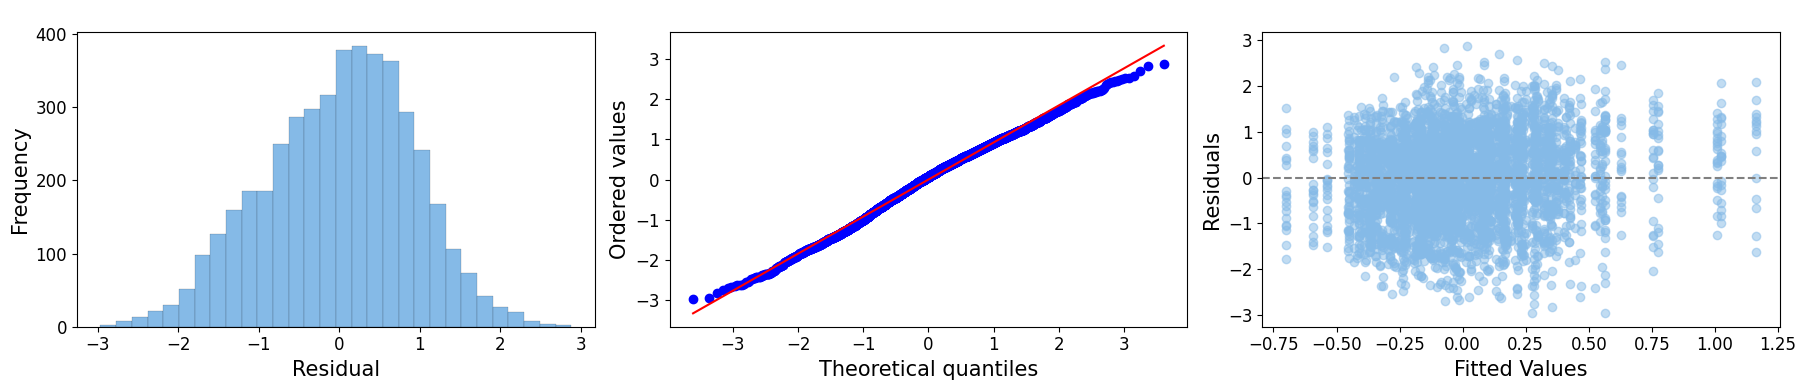


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [4]:
name = 'model1'
raw_covs = []
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8887                       
Min. group size:                    15                      Log-Likelihood:                     -6276.9588                   
Max. group size:                    20                      Converged:                          Ye

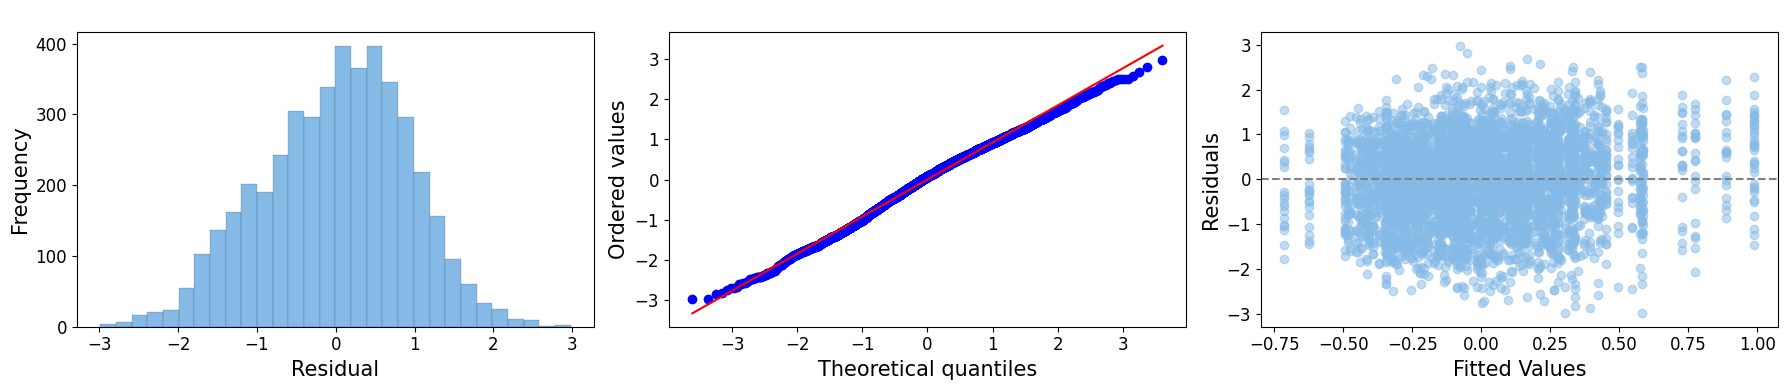


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [5]:
name = 'model2'
raw_covs = ['gender', 'education', 'age']
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8887                       
Min. group size:                    15                      Log-Likelihood:                     -6281.620

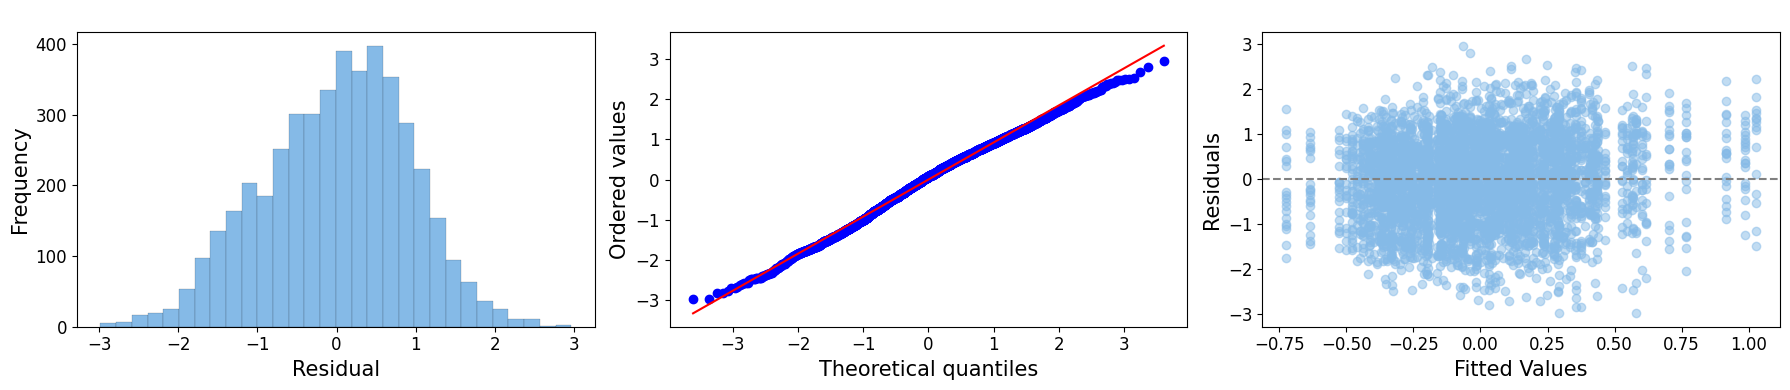


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [6]:
name = 'model3'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying']
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8886                       
Min. group size:                    

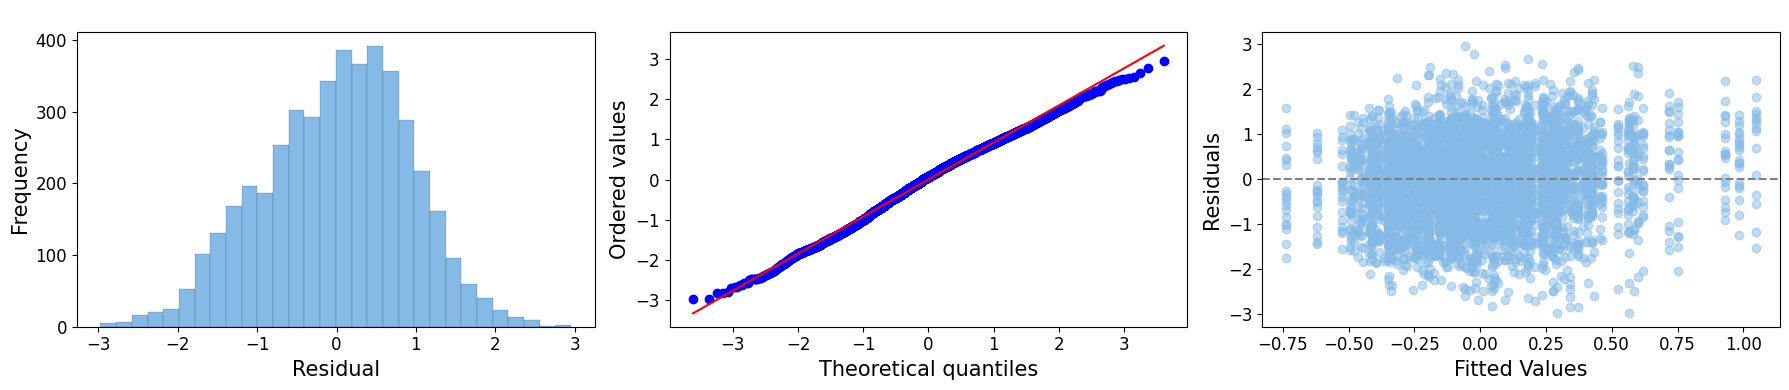


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [7]:
name = 'model4'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8886                       
Min. group size:

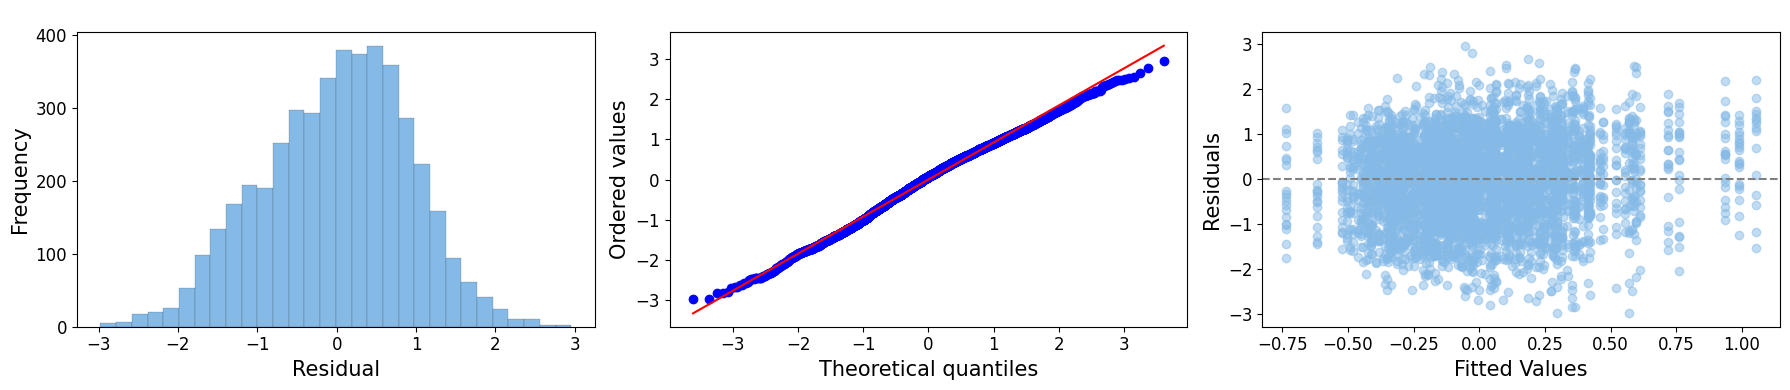


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [8]:
name = 'model5'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)

---

# Block 2 Data

**Dependent variable:** Absolute difference in house prices with boxcox-transformation and scaled and centered (boxcox_gap_house_price_scaled)

**Dependent variable:** Absolute difference in AI prices with boxcox-transformation and scaled and centered (boxcox_gap_ai_price_scaled)

In [9]:
data, houses, demographics, batch_info = als.load_valid_data('data_path')
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p1', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

### Run the models + check assumptions

#### House price

In [3]:
dependent = 'boxcox_gap_house_price_scaled'
save_plots = False


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4170                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.9728                       
Min. group size:                    8                       Log-Likelihood:                     -5916.0867                   
Max. group size:                    20                      Converged:                          Yes                          
Mean group size:                    17.7                        

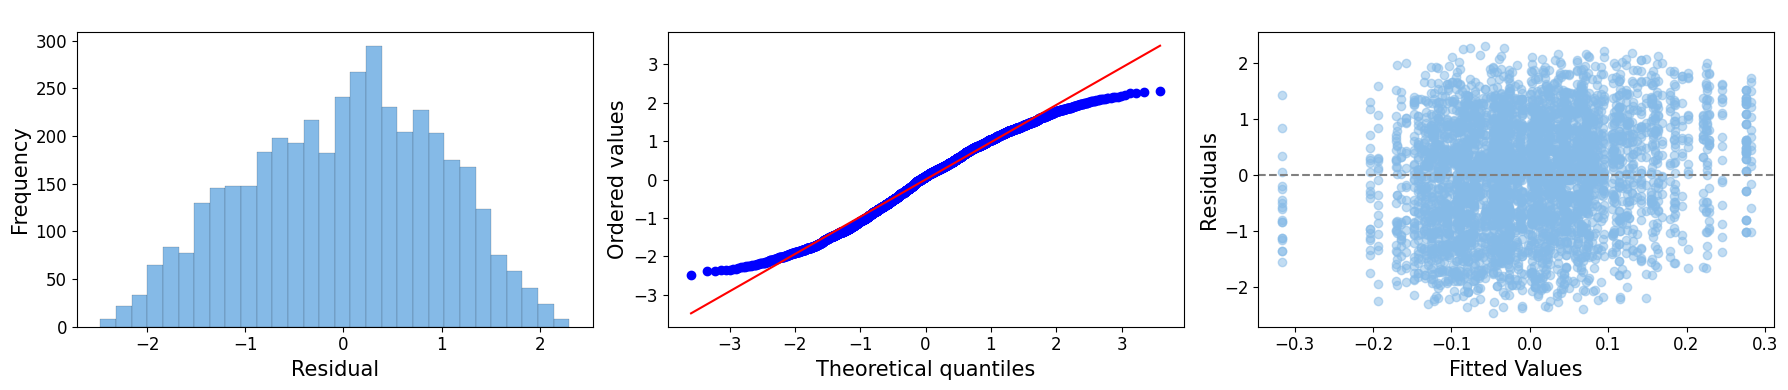


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [4]:
name = 'model1'
raw_covs = []
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4170                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.9725                       
Min. group size:                    8                       Log-Likelihood:                     -5919.3136                   
Max. group size:                    20                      Converged:                          Ye

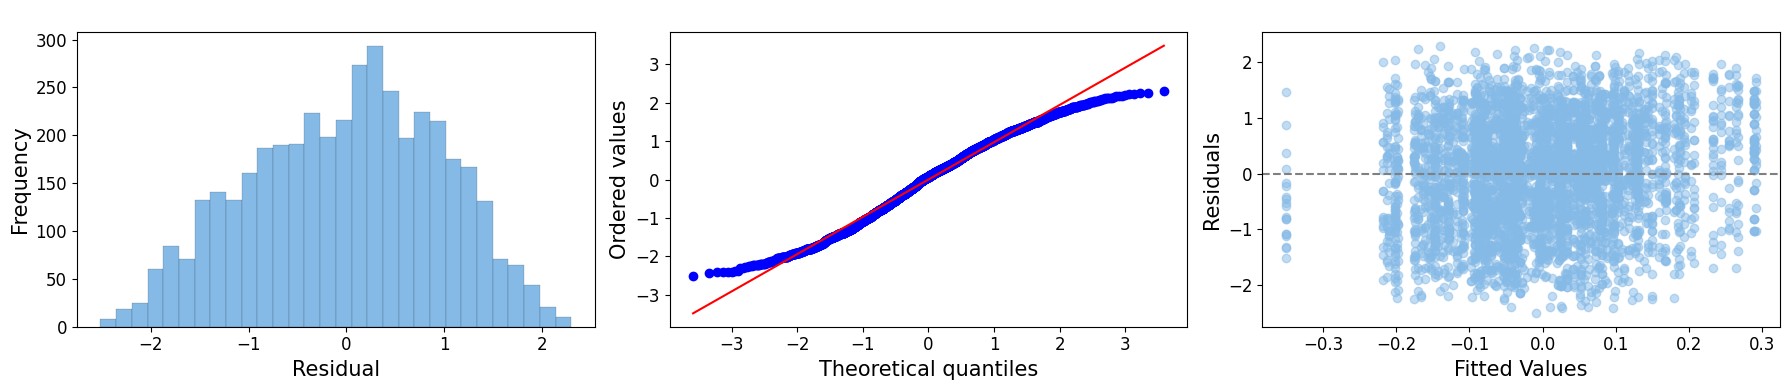


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [17]:
name = 'model2'
raw_covs = ['gender', 'education', 'age']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4170                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.9724                       
Min. group size:                    8                       Log-Likelihood:                     -5926.560

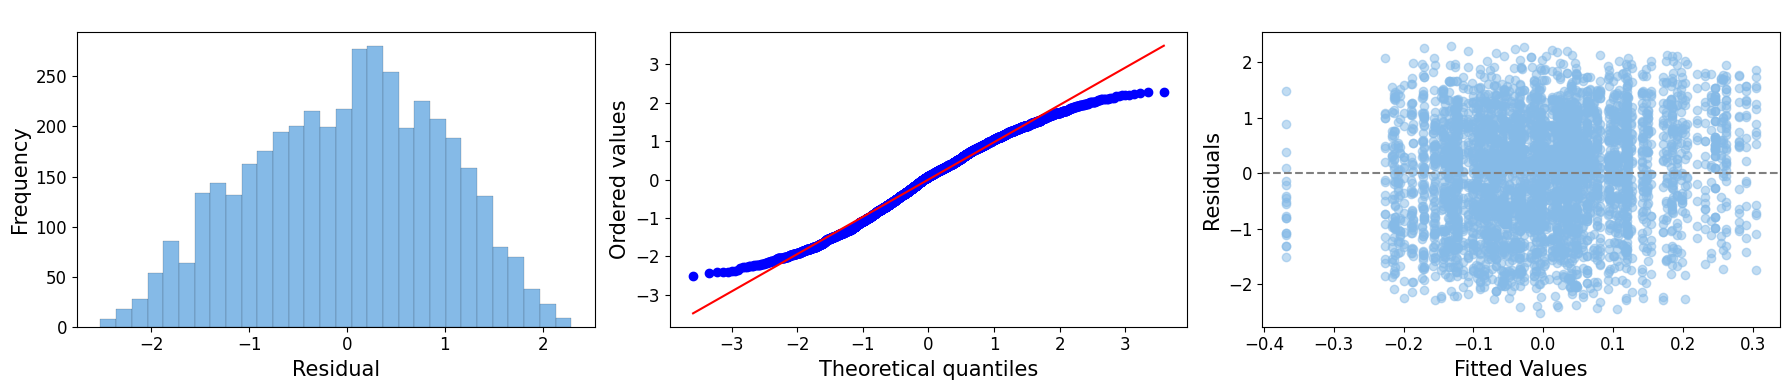


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [18]:
name = 'model3'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4170                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.9723                       
Min. group size:                    

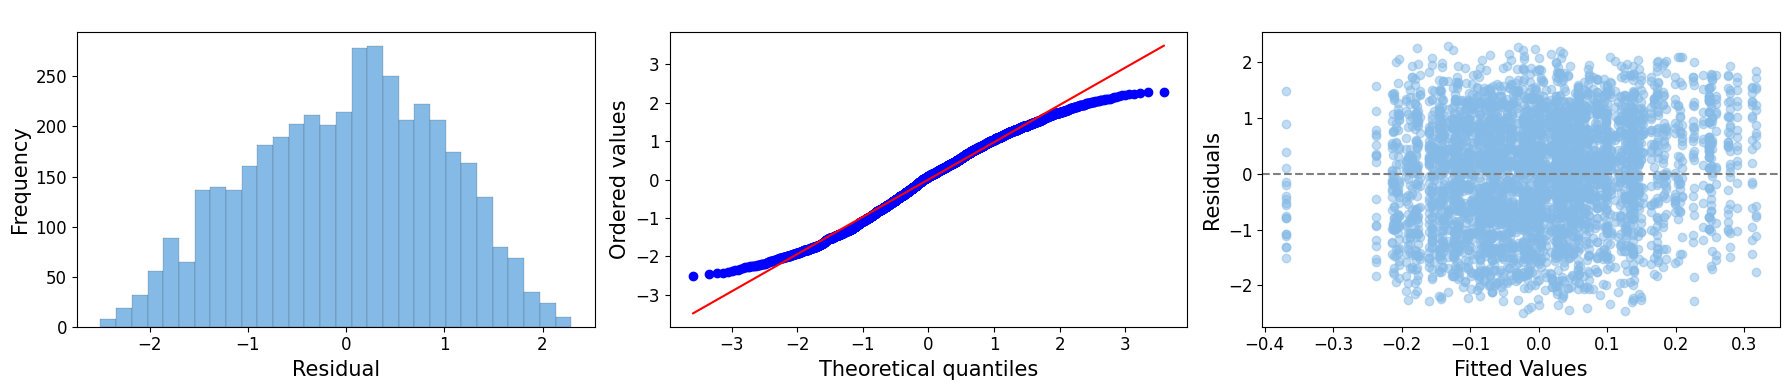


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [20]:
name = 'model4'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)
                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4170                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.9723                       
Min. group size:

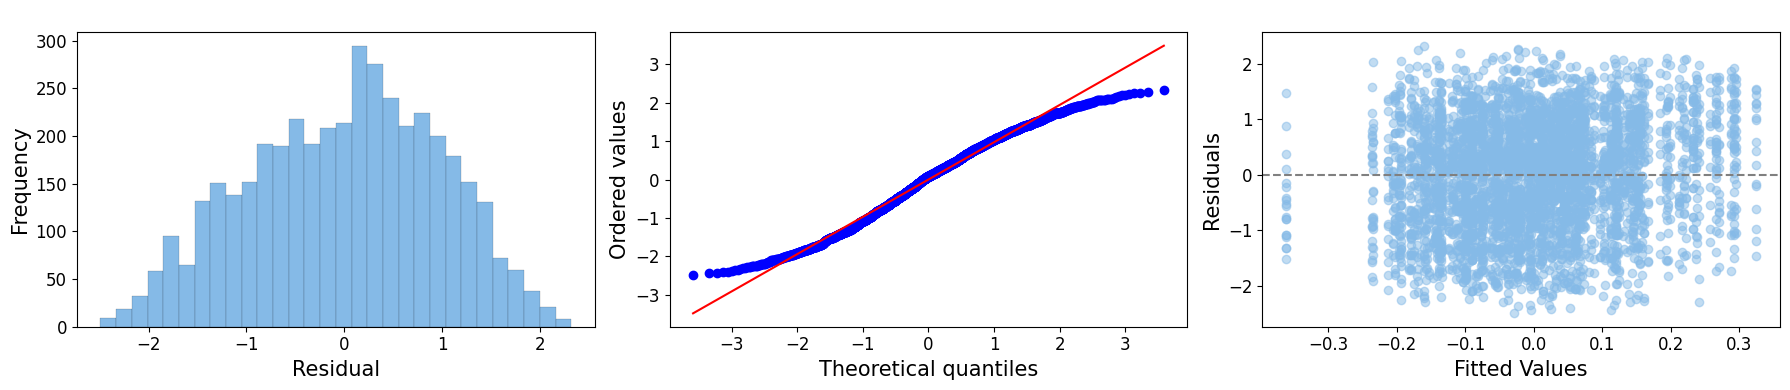


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [5]:
name = 'model5'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)

#### AI price

In [6]:
dependent = 'boxcox_gap_ai_price_scaled'
save_plots = False


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))
                                            Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  boxcox_gap_ai_price_scaled
No. Observations:                    4170                     Method:                              REML                      
No. Groups:                          236                      Scale:                               0.9544                    
Min. group size:                     8                        Log-Likelihood:                      -5901.8304                
Max. group size:                     20                       Converged:                           Yes                       
Mean group size:                     17.7                          

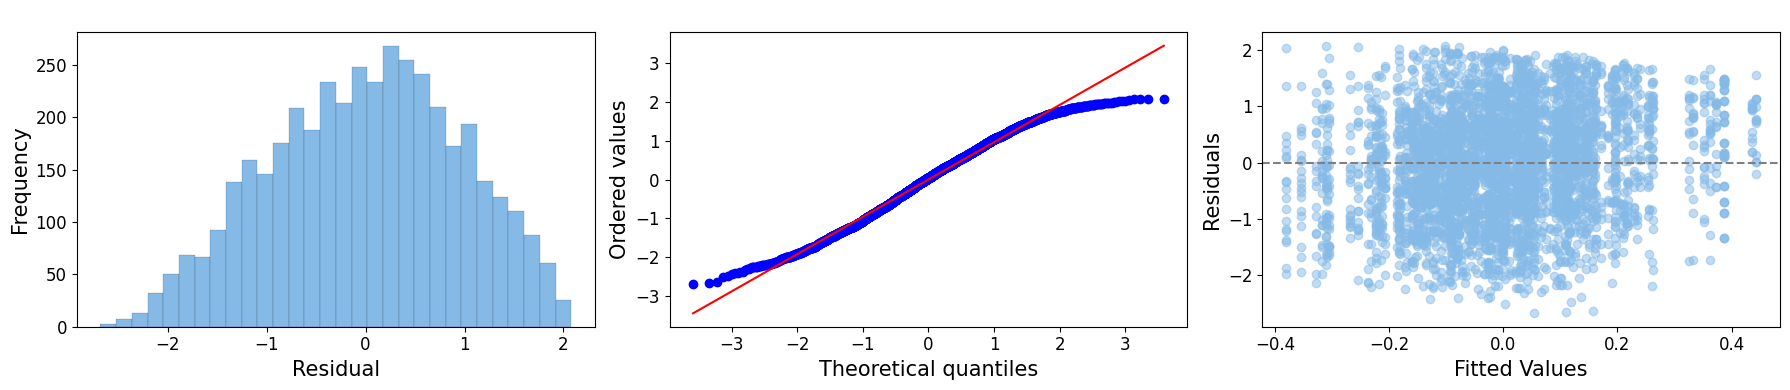


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [22]:
name = 'model1'
raw_covs = []
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age
                                            Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  boxcox_gap_ai_price_scaled
No. Observations:                    4170                     Method:                              REML                      
No. Groups:                          236                      Scale:                               0.9544                    
Min. group size:                     8                        Log-Likelihood:                      -5907.1765                
Max. group size:                     20                       Converged:                           Ye

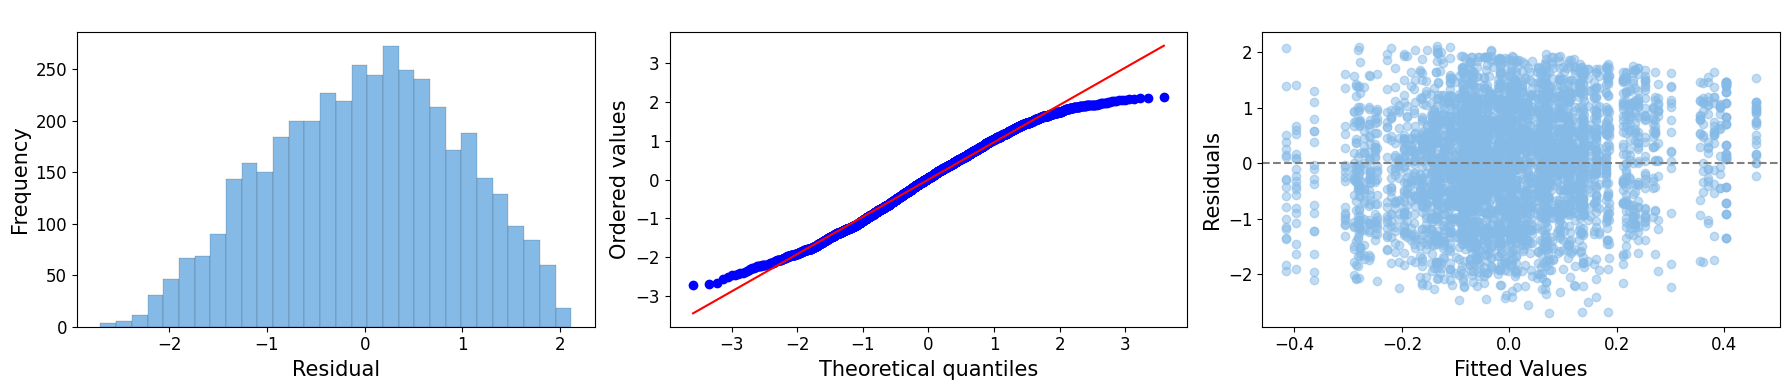


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [23]:
name = 'model2'
raw_covs = ['gender', 'education', 'age']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none"))+C(gender, Treatment(reference="female"))+C(education, Treatment(reference="bachelors"))+age'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))
                                            Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  boxcox_gap_ai_price_scaled
No. Observations:                    4170                     Method:                              REML                      
No. Groups:                          236                      Scale:                               0.9543                    
Min. group size:                     8                        Log-Likelihood:                      -5914.041

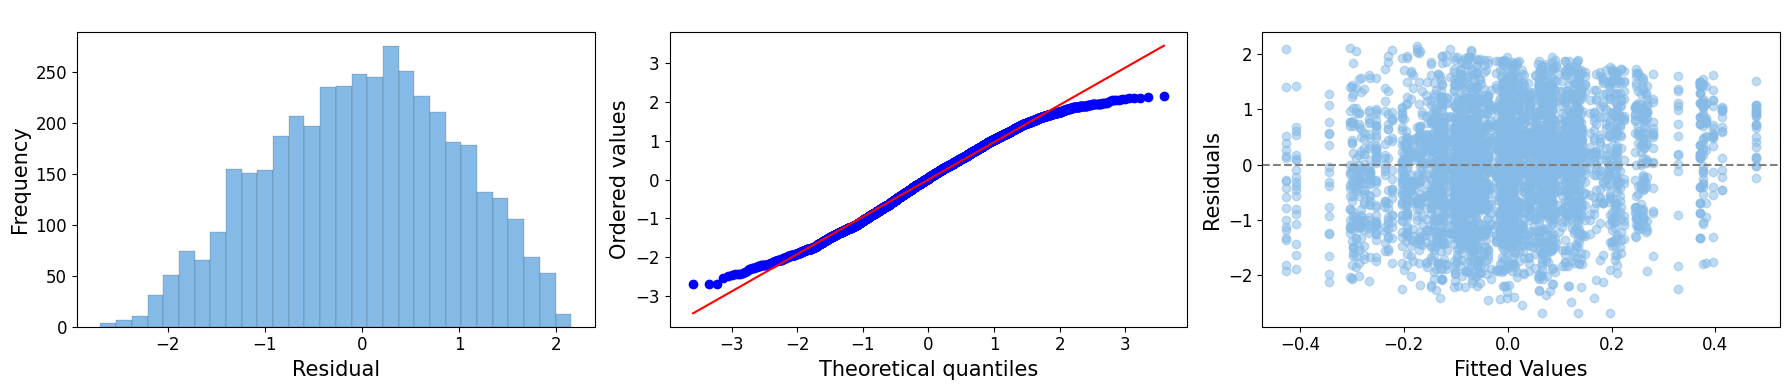


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [24]:
name = 'model3'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))
                                            Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  boxcox_gap_ai_price_scaled
No. Observations:                    4170                     Method:                              REML                      
No. Groups:                          236                      Scale:                               0.9543                    
Min. group size:                     8 

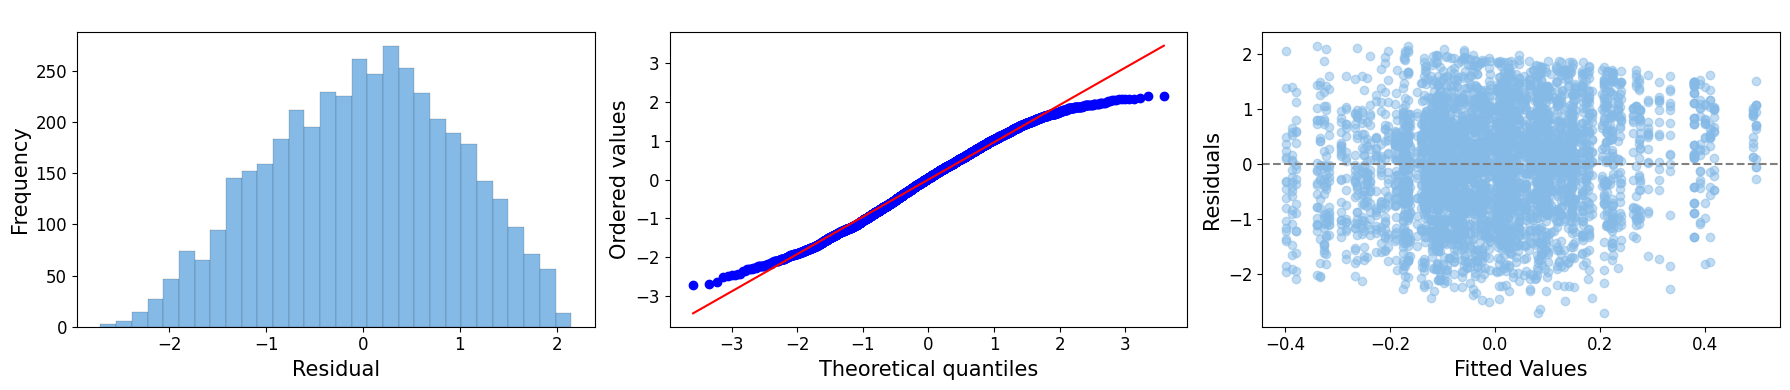


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [25]:
name = 'model4'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)
                                            Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  boxcox_gap_ai_price_scaled
No. Observations:                    4170                     Method:                              REML                      
No. Groups:                          236                      Scale:                               0.9542                    
Min. group size:   

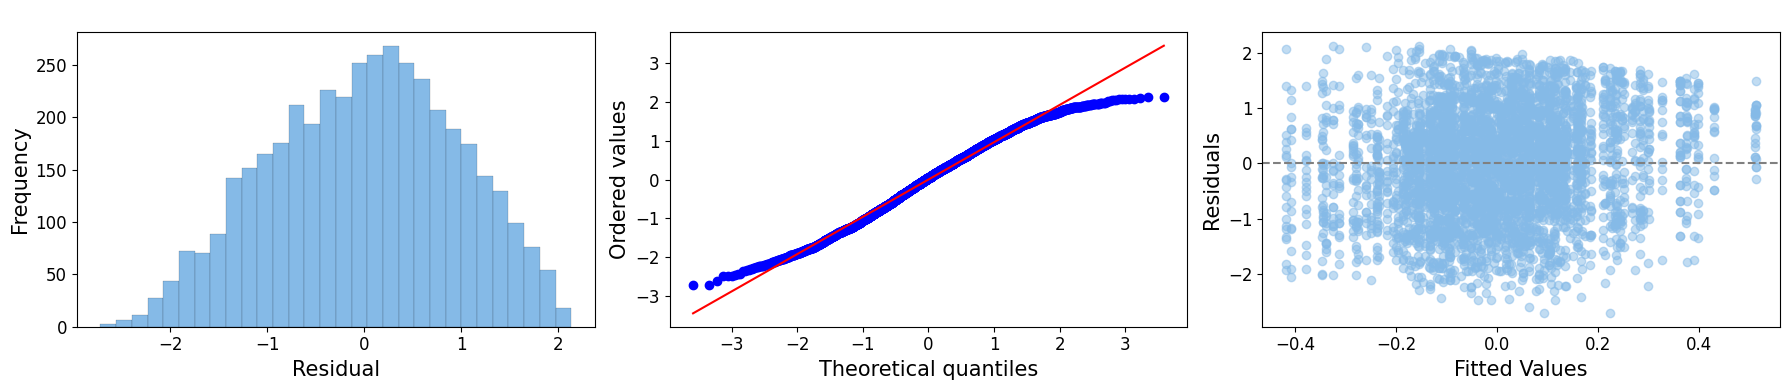


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [8]:
name = 'model5'
raw_covs = ['gender', 'education', 'age', 'practicalExperience', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode']
formula = f'{dependent} ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age + practicalExperience + C(dailyAIWork, Treatment(reference="daily")) + C(houseBuying, Treatment(reference="no")) + C(attributedUserExplanationViewMode, Treatment(reference="table")) + C(PublishingTime)'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)

---

# Block 3 Data

**Dependent variable:** AI reliance (binary)

All analysis were carried out using R. 

In [12]:
data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p2', transformation = 'boxcox')
phase_data['followAI'] = phase_data['followAI'].astype(int)

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

In [13]:
phase_data_hiddenFalse = phase_data[phase_data['featuresHidden']==False]
phase_data_hiddenTrue = phase_data[phase_data['featuresHidden']==True]

# # save data as csv files
# phase_data_hiddenFalse.to_csv('processed-data/final/p2_hiddenFalse.csv', index=False)
# phase_data_hiddenTrue.to_csv('processed-data/final/p2_hiddenTrue.csv', index=False)


--- 

# Visualizations

## Figure 2

In [ ]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None,
                              dh=0.05, barh=0.05, fs=None, maxasterix=None, idx=0, separation=0.08):
    """
    Annotate barplot with p-values, with optional stacking to avoid overlap.
    
    :param idx: index to stack multiple annotations above same bar
    :param separation: how much vertical spacing to add per idx (in axis units)
    """

    if isinstance(data, str):
        text = data
    else:
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax = plt.gca()
    ax_y0, ax_y1 = ax.get_ylim()
    y_range = ax_y1 - ax_y0

    # Add base and stack height
    total_dh = dh * y_range + idx * separation * y_range
    barh = barh * y_range

    y = max(ly, ry) + total_dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx + rx) / 2, y + barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs
    ax.text(*mid, text, **kwargs)

### Figure 2a

In [101]:
# -------------- NOTE --------------
# we cannot load the data directly from als.clean_data() as we did before
# because we need access to the scaler() that was used to scale the data 
# to be able to re-scale them to the original feature space for plotting the original values rather than scaled values

data, houses, demographics, batch_info = als.load_valid_data(data_path)

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from scipy.stats import boxcox

# specificy some parameters
phase='p0'
transformation = 'boxcox'
data = als.remove_outliers(data, ['propertyValue', 'aiPrediction'])

if phase=='p0':
    phase0 = data[data['phase']=='p0'] # get answers from p0 
    phase0 = phase0[['userID', 'houseId', 'propertyValue']] # choose relevant columns

    # merge data from p0 with demographics and house information
    phase0 = pd.merge(phase0, demographics, on='userID')
    phase0 = pd.merge(phase0, houses[['retailvalue', 'id']], left_on='houseId', right_on='id')
    phase0 = phase0.drop(['id'], axis=1) # remove redundant house id
    phase0 = pd.merge(phase0, batch_info[['Answer.surveycode', 'WorkTimeInSeconds', 'SubmitTime']], left_on='userID', right_on='Answer.surveycode', how='left')
    phase0 = phase0.drop(['Answer.surveycode'], axis=1) #remove redundant user id
    phase0 = als.disambiguate_user_ids(phase0)

    # # remove users with slowest 0.05 quantile 
    cutoff = phase0['WorkTimeInSeconds'].quantile(0.05)
    phase0 = phase0[phase0['WorkTimeInSeconds']>cutoff]

    # calculate gap between true price and user's estimated price
    phase0['gap_house_price'] = abs(phase0['retailvalue']-phase0['propertyValue'])
    
    # standardize dependent variable
    scaler = StandardScaler()
    
    if transformation == 'log':
        phase0[f'{transformation}_gap_house_price'] = np.log(phase0['gap_house_price'])
    elif transformation == 'sqrt':
        phase0[f'{transformation}_gap_house_price'] = np.sqrt(phase0['gap_house_price'])
    elif transformation == 'boxcox':
        phase0[f'{transformation}_gap_house_price'], lambda_bc = boxcox(phase0['gap_house_price'])
    
    
    continuous_predictors = ['houseId','propertyValue','age','theoreticalKnowledge', 'practicalExperience', 'retailvalue', 'WorkTimeInSeconds']
    for num in phase0.select_dtypes(include=['number']):
        phase0[num+'_scaled'] = scaler.fit_transform(phase0[[num]])

    # lastly scale dependent variable
    phase0['boxcox_gap_house_price'] = scaler.fit_transform(phase0[['boxcox_gap_house_price']])

    # merge 'PhD' and 'masters'
    phase0['education'] = phase0['education'].replace('phd', 'masters')
    # replace 'less_than_monthly' with 'monthly'
    phase0['dailyAIWork'] = phase0['dailyAIWork'].replace('less_than_monthly', 'monthly')

formula = 'boxcox_gap_house_price_scaled ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age'

import statsmodels.api as sm
model = sm.MixedLM.from_formula(formula, groups=phase0['userID'], data=phase0).fit()
# print(model.summary()) # check if model is correct 

                                            Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 boxcox_gap_house_price_scaled
No. Observations:                   4514                    Method:                             REML                         
No. Groups:                         236                     Scale:                              0.8887                       
Min. group size:                    15                      Log-Likelihood:                     -6276.9588                   
Max. group size:                    20                      Converged:                          Yes                          
Mean group size:                    19.1                                                                                     
-----------------------------------------------------------------------------------------------------------------------------
                                    

In [119]:
# Create a dataframe with typical values for covariates
# Use the mean for age and most common category for categorical covariates

treatment_levels = ['none', 'featureImportance', 'point', 'interval'] 

new_data = pd.DataFrame({
    'attributedUserExplanationType': treatment_levels,
    'gender': 'female', # reference category
    'education': 'bachelors', # reference category
    'age': phase0['age'].mean()
})

# Predict outcome means
adjusted_transformed = model.predict(new_data)

# Reverse scaling
adjusted_boxcox = scaler.inverse_transform(adjusted_transformed.values.reshape(-1, 1)).flatten()
from scipy.special import inv_boxcox  # works with lambda
adjusted_original = inv_boxcox(adjusted_boxcox, lambda_bc)

new_data['adjusted_mean'] = adjusted_original

n_boot = 100  
boot_preds = []

np.random.seed(100)

for _ in range(n_boot):
    # sample with replacement
    boot_df = phase0.sample(frac=1, replace=True)

    # apply boxcox transformation and scale the data
    boot_df['outcome_boxcox'] = boxcox(boot_df['gap_house_price'], lmbda=lambda_bc)
    boot_df['outcome_transformed'] = scaler.fit_transform(boot_df[['outcome_boxcox']])

    # Fit model
    boot_model = sm.MixedLM.from_formula('outcome_transformed ~ C(attributedUserExplanationType, Treatment(reference="none")) + C(gender, Treatment(reference="female")) + C(education, Treatment(reference="bachelors")) + age',
                             data=boot_df, groups=boot_df["userID"]).fit(reml=False,disp=False)

    # Predict on same new_data
    boot_pred_transformed = boot_model.predict(new_data)

    # Reverse transform (scale and Box-Cox)
    boot_pred_boxcox = scaler.inverse_transform(boot_pred_transformed.values.reshape(-1, 1)).flatten()
    boot_pred_original = inv_boxcox(boot_pred_boxcox, lambda_bc)

    boot_preds.append(boot_pred_original)

# Convert to array
boot_preds = np.array(boot_preds)  # shape: (n_boot, n_groups)

# compute standard deviation and standard error
sd_backscaled = boot_preds.std(axis=0)
se_backscaled = boot_preds.std(axis=0, ddof=1) / np.sqrt(boot_preds.shape[0])

# Optionally: 95% confidence intervals
ci_lower = np.percentile(boot_preds, 2.5, axis=0)
ci_upper = np.percentile(boot_preds, 97.5, axis=0)

new_data['se_backscaled'] = se_backscaled
new_data['sd_backscaled'] = sd_backscaled
new_data['ci_lower'] = ci_lower
new_data['ci_upper'] = ci_upper


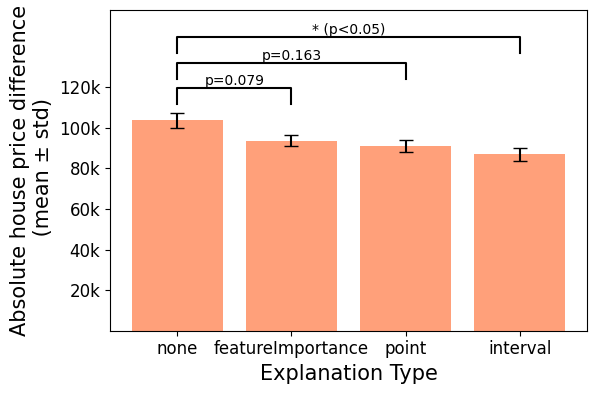

In [121]:
plt.figure(figsize=(6, 4))
plt.bar(x='attributedUserExplanationType', height='adjusted_mean', data=new_data, color='lightsalmon')

# Add error bars
plt.errorbar(x=range(len(new_data)),
             y=new_data['adjusted_mean'],
             yerr=new_data['sd_backscaled'],
             fmt='none', c='black', capsize=5)

current_ylim = plt.ylim()
plt.ylim(top=current_ylim[1] * 1.4)  # Increase top limit by 10%

y_tick_positions = [20000, 40000, 60000, 80000, 100000, 120000]
custom_labels = ['20k', '40k', '60k', '80k','100k', '120k']

plt.yticks(y_tick_positions, custom_labels)

plt.ylabel('Absolute house price difference\n (mean ± std)',fontsize=15)
plt.xlabel("Explanation Type", fontsize=15)
# plt.title("Adjusted Means from Mixed Effects Model")
plt.tight_layout()
plt.tick_params(axis='both', labelsize=12)  # Tick labels

barplot_annotate_brackets(0, 1, 'p=0.079', [0,1,2,3], list(new_data['adjusted_mean']), idx=0)
barplot_annotate_brackets(0, 2, 'p=0.163', [0,1,2,3], list(new_data['adjusted_mean']), idx=1)
barplot_annotate_brackets(0, 3, '* (p<0.05)', [0,1,2,3], list(new_data['adjusted_mean']), idx=2)

plt.show()

### Figure 2b

See R script for code on resampling, etc.

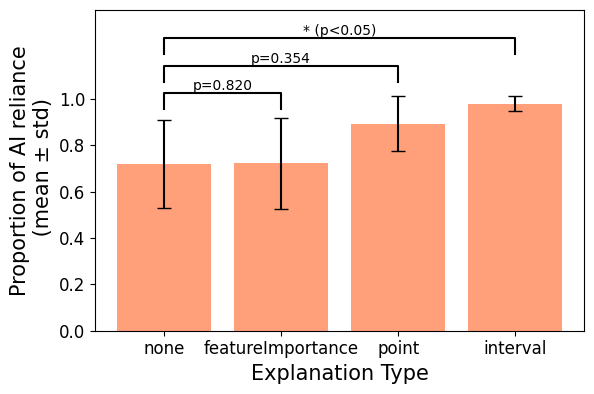

In [122]:
bootstrap_samples = pd.read_csv('./r/p2-hiddenFalse-232-bootstrap/female-bachelor-100-samples.csv')
bootstrap_samples

import pandas as pd
import numpy as np

summary = pd.DataFrame({
    'attributedUserExplanationType': bootstrap_samples.columns,
    'mean': bootstrap_samples.mean(),
    'se': bootstrap_samples.std() / np.sqrt(bootstrap_samples.count()),
    'sd': bootstrap_samples.std(),
    'ci_lower' : np.percentile(bootstrap_samples, 2.5, axis=0),
    'ci_upper':np.percentile(bootstrap_samples, 97.5, axis=0)
}).reset_index(drop=True)

desired_order = ['none', 'featureImportance', 'point', 'interval']

summary['attributedUserExplanationType'] = pd.Categorical(
    summary['attributedUserExplanationType'],
    categories=desired_order,
    ordered=True
)
summary = summary.sort_values('attributedUserExplanationType')  # optional but helps plotting


plt.figure(figsize=(6, 4))
# sns.barplot(x='attributedUserExplanationType', y='adjusted_mean', data=new_data, color='peachpuff', ci=None)
plt.bar(x='attributedUserExplanationType', height='mean', data=summary, color='lightsalmon')

# Add error bars
plt.errorbar(x=range(len(summary)),
             y=summary['mean'],
             yerr=summary['sd'],
             fmt='none', c='black', capsize=5)

current_ylim = plt.ylim()
plt.ylim(top=current_ylim[1] * 1.3)  # Increase top limit by 10%

y_tick_positions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
custom_labels = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0']

plt.yticks(y_tick_positions, custom_labels)

plt.ylabel('Proportion of AI reliance\n (mean ± std)',fontsize=15)
plt.xlabel("Explanation Type", fontsize=15)
# plt.title("Adjusted Means from Mixed Effects Model")
plt.tight_layout()
plt.tick_params(axis='both', labelsize=12)  # Tick labels

barplot_annotate_brackets(0, 1, 'p=0.820', [0,1,2,3], list(summary['mean']), idx=1.5)
barplot_annotate_brackets(0, 2, 'p=0.354', [0,1,2,3], list(summary['mean']), idx=1)
barplot_annotate_brackets(0, 3, '* (p<0.05)', [0,1,2,3], list(summary['mean']), idx=1.3)

plt.show()


## Figure 3

In [126]:
import seaborn as sns
from sklearn.metrics import root_mean_squared_error

data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p2', transformation = 'boxcox')
unique_users = phase_data.drop_duplicates(subset=['userID'])

phase_data['estimated-price'] = np.where(phase_data['followAI'], phase_data['predicted-price'], phase_data['propertyValue'])
phase_data['abs_error_pred'] = abs(phase_data['predicted-price'] - phase_data['retailvalue'])

# some prep functions for plotting
def scatter_with_smooth_only_false(data, color=None, **kwargs):
    # Scatterplot with hue, using Seaborn's default handling
    sns.scatterplot(
        data=data,
        x='mean_followAI',
        y='rmse',
        hue='followAI',
        palette='Blues',
        **kwargs
    )

    # LOWESS smoothing for followAI == False
    subset = data[data['followAI'] == False]
    if len(subset) >= 5:  # Only if enough data points
        smooth = lowess(subset['rmse'], subset['mean_followAI'], frac=0.5)

        # Match the default light blue used by hue=False in 'Blues' palette
        # You can also directly get the palette value from Seaborn
        blue_palette = sns.color_palette('Blues')
        light_blue = blue_palette[2]  # index 2 or 3 is often the light blue tone

        plt.plot(
            smooth[:, 0],
            smooth[:, 1],
            color=light_blue,
            linestyle='-',
            linewidth=2,
            # label="Smooth (followAI=False)"
        )

def scatter_with_smooth_only_true(data, color=None, **kwargs):
    # Scatterplot with hue, using Seaborn's default handling
    sns.scatterplot(
        data=data,
        x='mean_followAI',
        y='rmse',
        hue='followAI',
        palette='Blues',
        **kwargs
    )

    # LOWESS smoothing for followAI == False
    subset = data[data['followAI'] == True]
    if len(subset) >= 5:  # Only if enough data points
        smooth = lowess(subset['rmse'], subset['mean_followAI'], frac=0.5)

        # Match the default light blue used by hue=False in 'Blues' palette
        # You can also directly get the palette value from Seaborn
        blue_palette = sns.color_palette('Blues')
        blue = blue_palette[3]  # index 2 or 3 is often the light blue tone

        plt.plot(
            smooth[:, 0],
            smooth[:, 1],
            color=blue,
            linestyle='-',
            linewidth=2,
            # label="Smooth (followAI=True)"
        )

### Figure 3a: features shown

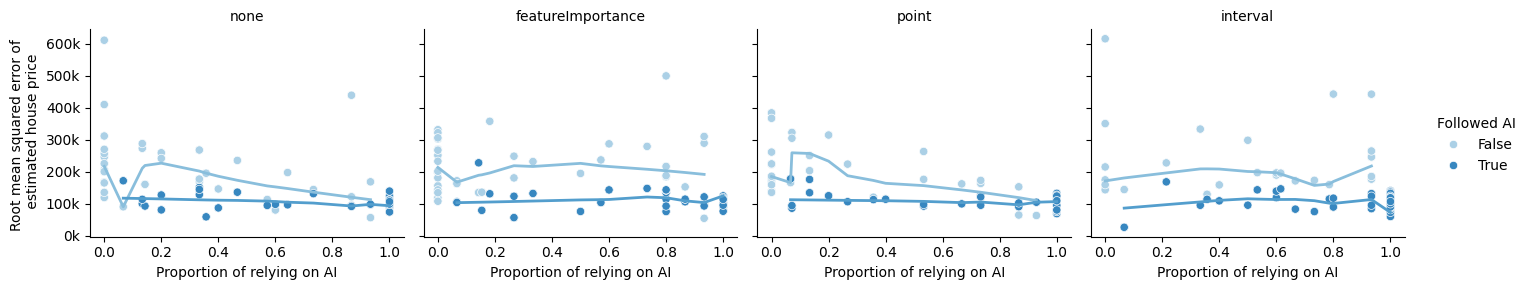

In [127]:
phase_data = phase_data[phase_data['featuresHidden']==False]

phase_data_users = phase_data.groupby('userID')['followAI'].agg(['mean']).reset_index()
phase_data_users = pd.merge(phase_data_users, unique_users[['userID','attributedUserExplanationType', 'gender']], on='userID')
phase_data_users['mean'] = phase_data_users['mean'].astype(float)
phase_data_users = phase_data_users.rename({'mean':'mean_followAI'}, axis=1)

rmse_by_user = phase_data.groupby(['userID', 'followAI']).apply(lambda g: root_mean_squared_error(g['retailvalue'], g['estimated-price']))
rmse_by_user = rmse_by_user.reset_index(name='rmse')
rmse_by_user = rmse_by_user.merge(phase_data_users, on='userID')

# Ensure correct category ordering for faceting
desired_order = ['none', 'featureImportance', 'point', 'interval']
rmse_by_user['attributedUserExplanationType'] = pd.Categorical(
    rmse_by_user['attributedUserExplanationType'],
    categories=desired_order,
    ordered=True
)

# Set up FacetGrid with 1 row, 4 columns (or adjust as needed)
g = sns.FacetGrid(
    rmse_by_user,
    col='attributedUserExplanationType',
    col_wrap=4,   # Or col_wrap=4 if you want all in one row
    height=3,
    sharex=True,
    sharey=True,
    aspect=1.2
)

# Map scatterplot to each facet
g.map_dataframe(
    sns.scatterplot,
    x='mean_followAI',
    y='rmse',
    hue='followAI',
    palette='Blues'
)
from statsmodels.nonparametric.smoothers_lowess import lowess


# Map custom plotting function to FacetGrid
g.map_dataframe(scatter_with_smooth_only_false)
g.map_dataframe(scatter_with_smooth_only_true)

y_tick_positions = [0, 100000, 200000, 300000, 400000, 500000, 600000]
custom_labels = ['0k', '100k', '200k', '300k', '400k', '500k', '600k']
plt.yticks(y_tick_positions, custom_labels)

# Adjust aesthetics
g.set_axis_labels("Proportion of relying on AI", "Root mean squared error of \n estimated house price")
g.set_titles(col_template="{col_name}")
g.add_legend(title='Followed AI')
g.tight_layout()
plt.show()


### Figure 3b: features hidden

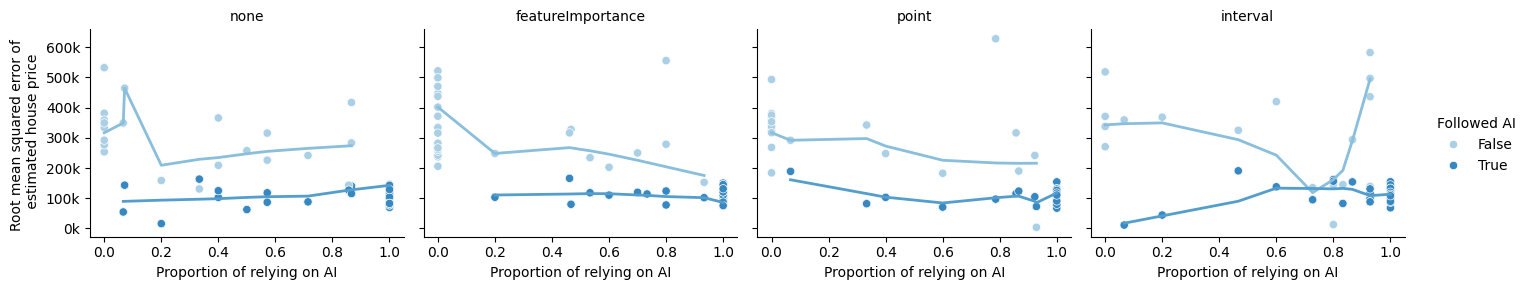

In [125]:
phase_data = phase_data[phase_data['featuresHidden']==True]

phase_data_users = phase_data.groupby('userID')['followAI'].agg(['mean']).reset_index()
phase_data_users = pd.merge(phase_data_users, unique_users[['userID','attributedUserExplanationType', 'gender']], on='userID')
phase_data_users['mean'] = phase_data_users['mean'].astype(float)
phase_data_users = phase_data_users.rename({'mean':'mean_followAI'}, axis=1)

rmse_by_user = phase_data.groupby(['userID', 'followAI']).apply(lambda g: root_mean_squared_error(g['retailvalue'], g['estimated-price']))
rmse_by_user = rmse_by_user.reset_index(name='rmse')
rmse_by_user = rmse_by_user.merge(phase_data_users, on='userID')

# Ensure correct category ordering for faceting
desired_order = ['none', 'featureImportance', 'point', 'interval']
rmse_by_user['attributedUserExplanationType'] = pd.Categorical(
    rmse_by_user['attributedUserExplanationType'],
    categories=desired_order,
    ordered=True
)

# Set up FacetGrid with 1 row, 4 columns (or adjust as needed)
g = sns.FacetGrid(
    rmse_by_user,
    col='attributedUserExplanationType',
    col_wrap=4,   # Or col_wrap=4 if you want all in one row
    height=3,
    sharex=True,
    sharey=True,
    aspect=1.2
)

# Map scatterplot to each facet
g.map_dataframe(
    sns.scatterplot,
    x='mean_followAI',
    y='rmse',
    hue='followAI',
    palette='Blues'
)
from statsmodels.nonparametric.smoothers_lowess import lowess


# Map custom plotting function to FacetGrid
g.map_dataframe(scatter_with_smooth_only_false)
g.map_dataframe(scatter_with_smooth_only_true)

y_tick_positions = [0, 100000, 200000, 300000, 400000, 500000, 600000]
custom_labels = ['0k', '100k', '200k', '300k', '400k', '500k', '600k']
plt.yticks(y_tick_positions, custom_labels)

# Adjust aesthetics
g.set_axis_labels("Proportion of relying on AI", "Root mean squared error of \n estimated house price")
g.set_titles(col_template="{col_name}")
g.add_legend(title='Followed AI')
g.tight_layout()
plt.show()


## Figure 4

### Figure 4a

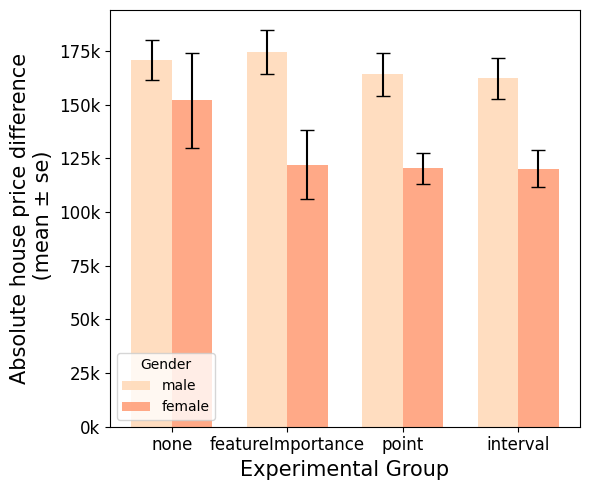

In [137]:
data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p0', transformation = 'boxcox')

# Compute user-level mean gap
user_means = phase_data.groupby('userID').agg({
    'gap_house_price': 'mean',
    'attributedUserExplanationType': 'first',
    'gender': 'first'
}).reset_index()

# Grouped summary
summary = user_means.groupby(['attributedUserExplanationType', 'gender'])['gap_house_price'].agg(['mean', 'sem']).reset_index()

custom_palette = {'gender':{
    'male': 'peachpuff',   
    'female': 'lightsalmon'  
    }}

desired_order = ['none', 'featureImportance', 'point', 'interval']

summary['attributedUserExplanationType'] = pd.Categorical(
    summary['attributedUserExplanationType'],
    categories=desired_order,
    ordered=True
)

summary = summary.sort_values('attributedUserExplanationType') 

# Get unique categories
x_labels = summary['attributedUserExplanationType'].unique()
hue_labels = ['male', 'female']

# Bar width and positions
bar_width = 0.35
x = np.arange(len(x_labels))

plt.figure(figsize=(6, 5))

for i, gender in enumerate(hue_labels):
    subdata = summary[summary['gender'] == gender]
    plt.bar(
        x + i * bar_width,
        subdata['mean'],
        yerr=subdata['sem'],
        width=bar_width,
        label=gender,
        capsize=5,
        alpha=0.9,
        color=custom_palette['gender'][gender]
    )

y_tick_positions = [0, 25000, 50000, 75000, 100000, 125000, 150000, 175000]
custom_labels = ['0k', '25k', '50k', '75k', '100k', '125k', '150k', '175k']
plt.yticks(y_tick_positions, custom_labels)
plt.xticks(x + bar_width / 2, x_labels)
plt.xlabel('Experimental Group', fontsize=15)
plt.ylabel('Absolute house price difference\n (mean ± se)', fontsize=15)
plt.tick_params(axis='both', labelsize=12)  # Tick labels
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


### Figure 4b

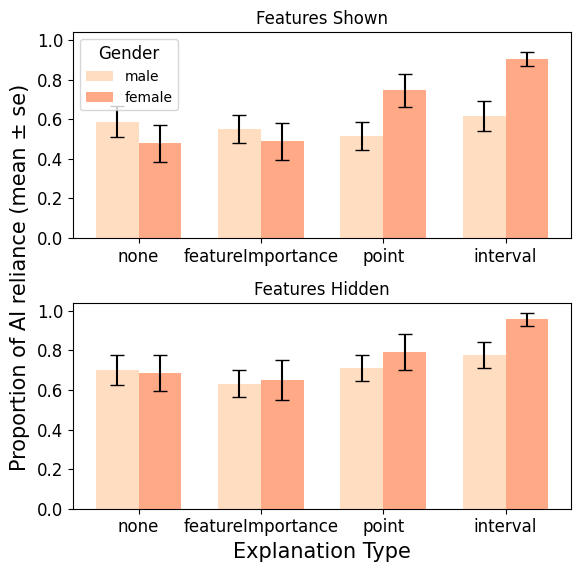

In [131]:
# summary function
def prepare_summary(df, unique_users):
    phase_data_users = df.groupby('userID')['followAI'].agg(['mean']).reset_index()
    phase_data_users = pd.merge(phase_data_users, unique_users, on='userID')
    phase_data_users['mean_followAI'] = phase_data_users['mean'].astype(float)

    summary = phase_data_users.groupby(['attributedUserExplanationType', 'gender'])['mean_followAI'].agg(['mean', 'sem']).reset_index()
    desired_order = ['none', 'featureImportance', 'point', 'interval']
    summary['attributedUserExplanationType'] = pd.Categorical(summary['attributedUserExplanationType'], categories=desired_order, ordered=True)
    return summary.sort_values('attributedUserExplanationType')

# Prepare summaries
summary_false = prepare_summary(phase_data_hiddenFalse, unique_users)
summary_true = prepare_summary(phase_data_hiddenTrue, unique_users)

# Plot settings
x_labels = ['none', 'featureImportance', 'point', 'interval']
hue_labels = ['male', 'female']
bar_width = 0.35
x = np.arange(len(x_labels))

custom_palette = {
    'gender': {   
        'female': 'lightsalmon',
        'male': 'peachpuff' 
    }
}

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=False, sharey=True)

for ax, summary, title in zip(axes, [summary_false, summary_true], ['Features Shown', 'Features Hidden']):
    for i, gender in enumerate(hue_labels):
        subdata = summary[summary['gender'] == gender]
        ax.bar(
            x + i * bar_width,
            subdata['mean'],
            yerr=subdata['sem'],
            width=bar_width,
            label=gender,
            capsize=5,
            alpha=0.9,
            color=custom_palette['gender'][gender]
        )
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(x_labels)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

# shared y-label using the middle of the figure
fig.text(0.04, 0.5, 'Proportion of AI reliance (mean ± se)', va='center', rotation='vertical', fontsize=15)

# have the legend only once 
axes[0].legend(title='Gender', fontsize=10, title_fontsize=12, loc='upper left')

# have the x-label (Explanation type) only once
axes[1].set_xlabel('Explanation Type', fontsize=15)

plt.tight_layout(rect=[0.06, 0, 1, 0.97])  # leave room for shared y-axis label
plt.show()


## Figure 5

In [7]:
data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p0', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

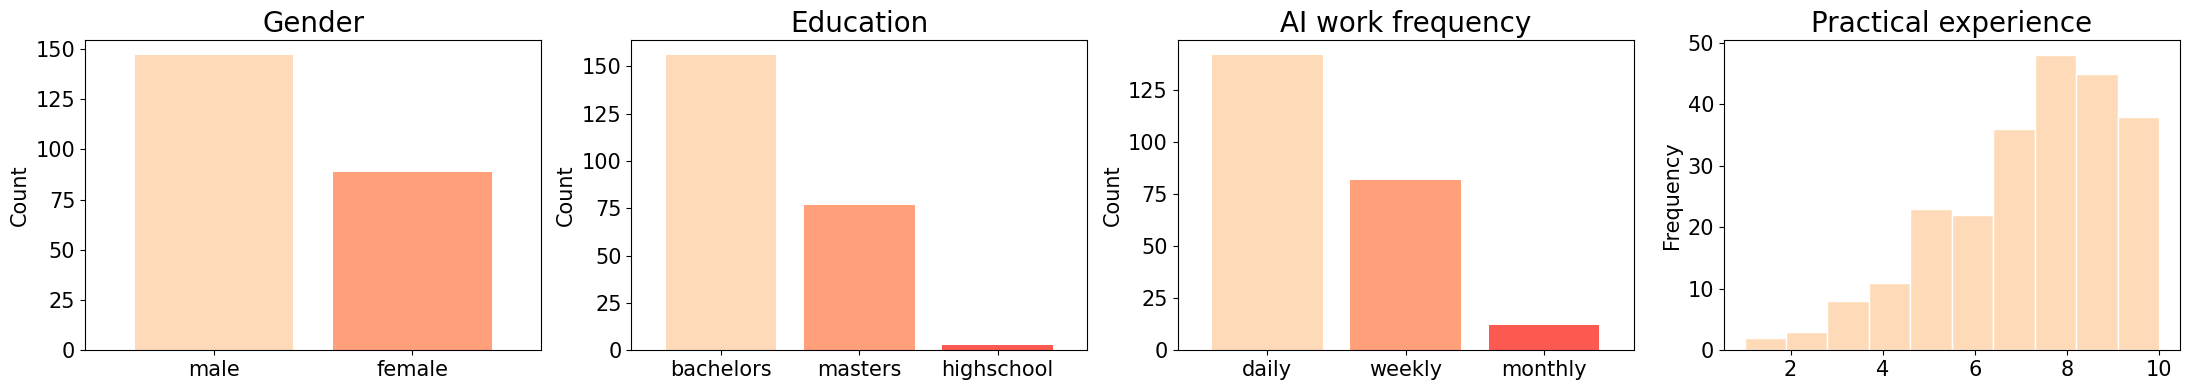

In [35]:
import matplotlib.pyplot as plt

# Custom palette dictionary
custom_palette = {
    'gender': {
        'male': 'peachpuff',   
        'female': 'lightsalmon'  
    },
    'education': {
        'bachelors': 'peachpuff',
        'masters': 'lightsalmon',
        'highschool': '#fc5a50'
    },
    'dailyAIWork': {
        'daily': 'peachpuff',
        'weekly': 'lightsalmon',
        'monthly': '#fc5a50'
    }
}

# Variables to plot
# categorical_features = ['gender', 'education', 'dailyAIWork']
categorical_features = {
    'gender':'Gender',
    'education': 'Education',
    'dailyAIWork': 'AI work frequency'
}
continuous_feature = 'practicalExperience'

# Create a row of 4 subplots
fig, axs = plt.subplots(1, 4, figsize=(22, 4))  

# ---- 1) Categorical plots ----
for ax, feature in zip(axs[:3], categorical_features):
    counts = (
        unique_users[feature]
        .value_counts()
        .reindex(custom_palette[feature].keys(), fill_value=0)
    )
    
    counts.plot(
        kind="bar",
        ax=ax,
        color=[custom_palette[feature][cat] for cat in counts.index],
        width=0.8
    )
    
    ax.set_title(categorical_features[feature], fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
    ax.grid(False)

# ---- 2) Histogram for continuous variable ----
axs[3].hist(
    unique_users[continuous_feature].dropna(),
    bins=10,
    color="peachpuff",
    edgecolor="white",
    alpha=1
)

axs[3].set_title('Practical experience', fontsize=20)
# axs[3].set_xlabel(continuous_feature, fontsize=12)
axs[3].set_ylabel("Frequency", fontsize=15)
axs[3].tick_params(axis='both', labelsize=15)
axs[3].grid(False)

plt.tight_layout()
plt.show()


point


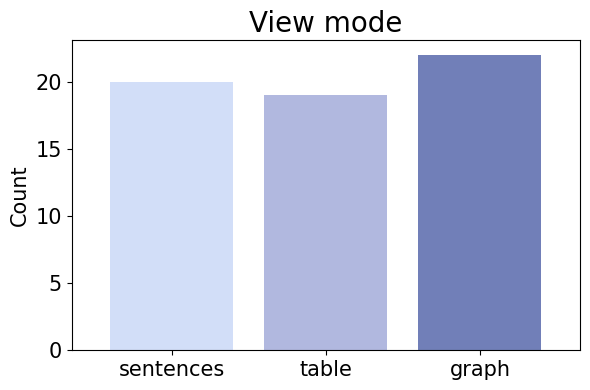

featureImportance


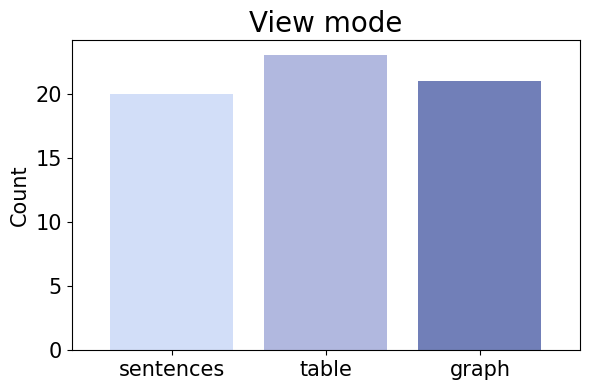

none


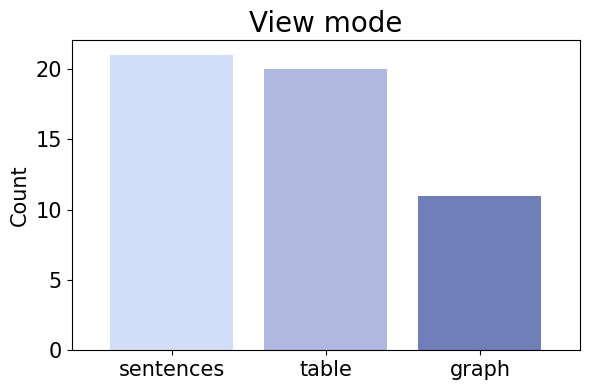

interval


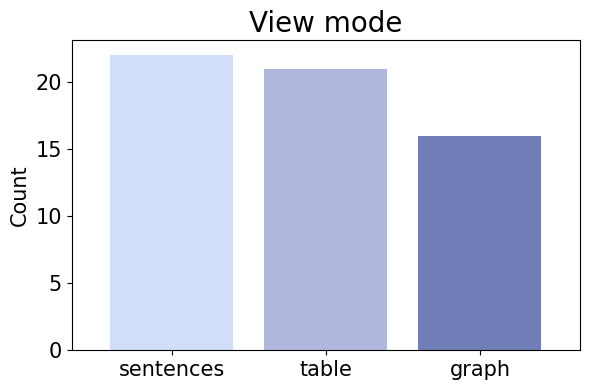

In [33]:
import matplotlib.pyplot as plt

# Custom palette for view mode
custom_palette = {
    'attributedUserExplanationViewMode': {
        'sentences': '#D2DEF8',
        'table': '#B1B8DF',
        'graph': '#717FB8'
    }
}

# Assume you have a column called 'explanationType' with 4 groups
groups = unique_users['attributedUserExplanationType'].unique()

for group in groups:
    subset = unique_users[unique_users['attributedUserExplanationType'] == group]
    
    counts = (
        subset['attributedUserExplanationViewMode']
        .value_counts()
        .reindex(custom_palette['attributedUserExplanationViewMode'].keys(), fill_value=0)
    )
    
    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot(
        kind="bar",
        ax=ax,
        color=[custom_palette['attributedUserExplanationViewMode'][cat] for cat in counts.index],
        width=0.8
    )
    
    print(group)
    ax.set_title(f"View mode", fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
    ax.grid(False)
    
    plt.tight_layout()
    plt.show()


---

# Gender

### Correlations

In [134]:
data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p0', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

In [24]:
covariates = ['gender', 'education', 'age', 'practicalExperience', 'theoreticalKnowledge', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode','PublishingTime']
high_corr_pearson, high_corr_spearman, pearson_matrix, spearman_matrix = als.show_high_correlations(unique_users[covariates], threshold=0.7)

In [25]:
spearman_matrix.round(3)

,gender,education,age,practicalExperience,theoreticalKnowledge,dailyAIWork,houseBuying,attributedUserExplanationViewMode,PublishingTime
gender,1.000,0.369,0.221,0.132,0.185,0.072,0.089,0.023,0.231
education,0.369,1.000,0.426,0.252,0.217,0.056,0.044,0.023,0.256
age,0.221,0.426,1.000,0.001,0.026,0.064,0.027,0.071,0.126
practicalExperience,0.132,0.252,0.001,1.000,0.696,0.264,0.215,0.089,0.012
theoreticalKnowledge,0.185,0.217,0.026,0.696,1.000,0.189,0.132,0.021,0.042
dailyAIWork,0.072,0.056,0.064,0.264,0.189,1.000,0.125,0.073,0.190
houseBuying,0.089,0.044,0.027,0.215,0.132,0.125,1.000,0.040,0.046
attributedUserExplanationViewMode,0.023,0.023,0.071,0.089,0.021,0.073,0.040,1.000,0.039
PublishingTime,0.231,0.256,0.126,0.012,0.042,0.190,0.046,0.039,1.000


### Statistical tests for differences in distributions

In [27]:
import pandas as pd
from scipy.stats import ks_2samp, chi2_contingency

categorical_features = ['education', 'dailyAIWork', 'houseBuying', 'attributedUserExplanationViewMode', 'PublishingTime']
continuous_features = ['age', 'practicalExperience', 'theoreticalKnowledge']


# Initialize result containers
ks_results = {}
chi2_results = {}

# Filter your dataframe to just male and female for simplicity
df_gendered = unique_users[unique_users['gender'].isin(['male', 'female'])]

# ----------------- K-S Test (Continuous Features) -----------------
for feature in continuous_features:
    group1 = df_gendered[df_gendered['gender'] == 'male'][feature].dropna()
    group2 = df_gendered[df_gendered['gender'] == 'female'][feature].dropna()

    statistic, p_value = ks_2samp(group1, group2)
    ks_results[feature] = {
        'ks_statistic': statistic,
        'p_value': p_value
    }

# Chi-Square Test (Categorical Features) 
for feature in categorical_features:
    contingency_table = pd.crosstab(df_gendered[feature], df_gendered['gender'])
    
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] == 2:
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        chi2_results[feature] = {
            'chi2_statistic': chi2,
            'p_value': p,
            'degrees_of_freedom': dof
        }
    else:
        chi2_results[feature] = {
            'error': 'Insufficient data for test (e.g., only one category present)'
        }

# print results
print("\nChi-Square Test Results (Categorical Features):")
for feature, result in chi2_results.items():
    if 'error' in result:
        print(f"{feature}: {result['error']}")
    else:
        print(f"{feature}: Chi2 = {result['chi2_statistic']:.2f}, p = {result['p_value']:.3f}, dof = {result['degrees_of_freedom']}")

print('\n')

print("Kolmogorov-Smirnov Test Results (Continuous Features):")
for feature, result in ks_results.items():
    print(f"{feature}: KS statistic = {result['ks_statistic']:.2f}, p = {result['p_value']:.3f}")


Chi-Square Test Results (Categorical Features):
education: Chi2 = 32.96, p = 0.000, dof = 2
dailyAIWork: Chi2 = 1.86, p = 0.394, dof = 2
houseBuying: Chi2 = 1.10, p = 0.294, dof = 1
attributedUserExplanationViewMode: Chi2 = 0.24, p = 0.885, dof = 2
PublishingTime: Chi2 = 11.67, p = 0.001, dof = 1


Kolmogorov-Smirnov Test Results (Continuous Features):
age: KS statistic = 0.31, p = 0.000
practicalExperience: KS statistic = 0.17, p = 0.077
theoreticalKnowledge: KS statistic = 0.19, p = 0.029


### Distribution plots

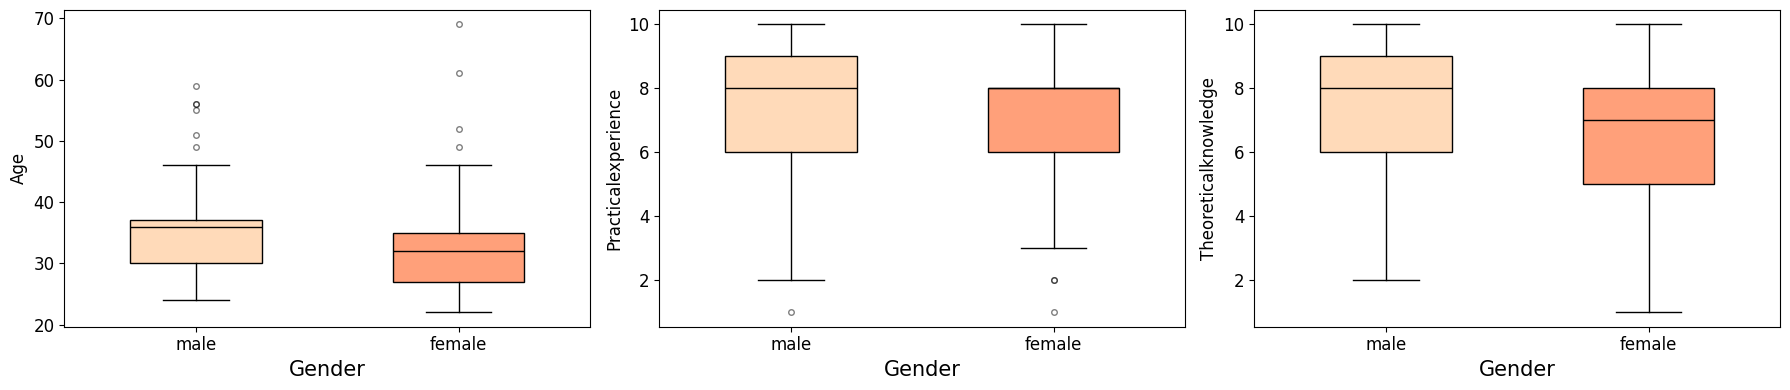

In [136]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Continuous features to plot
con_features = ['age', 'practicalExperience', 'theoreticalKnowledge']

# Fixed label + color mapping (ensures consistent order & colors)
gender_order = ['male', 'female']
colors = {'male': 'peachpuff', 'female': 'lightsalmon'}

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

for ax, feature in zip(axs, con_features):
    # Prepare data by fixed gender order
    data_by_gender = [
        unique_users[unique_users['gender'] == g][feature].dropna()
        for g in gender_order
    ]

    # Create boxplot
    bp = ax.boxplot(
        data_by_gender,
        patch_artist=True,
        widths=0.5,
        labels=gender_order,
        boxprops=dict(linewidth=1),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )

    # Apply consistent colors based on gender_order
    for patch, g in zip(bp['boxes'], gender_order):
        patch.set_facecolor(colors[g])

    # Styling
    ax.set_xlabel('Gender', fontsize=15)
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(False)

plt.tight_layout()
plt.show()



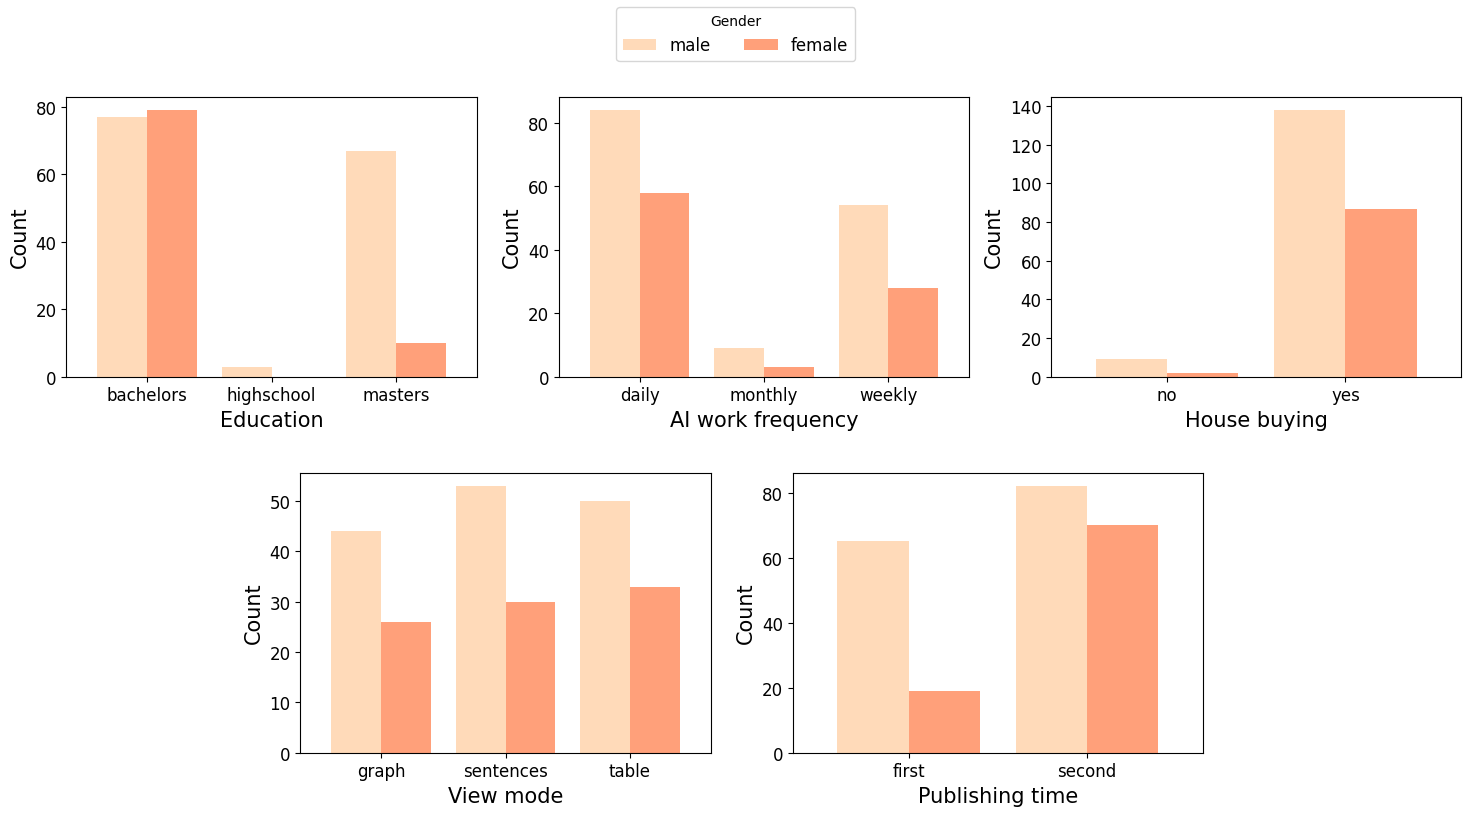

In [135]:
import matplotlib.pyplot as plt

categorical_features = {
    'education': 'Education',
    'dailyAIWork': 'AI work frequency',
    'houseBuying': 'House buying',
    'attributedUserExplanationViewMode': 'View mode',
    'PublishingTime': 'Publishing time'
}

# Recode PublishingTime values
unique_users['PublishingTime'] = unique_users['PublishingTime'].replace({0: 'first', 1: 'second'})

# Fixed label + color mapping
gender_order = ['male', 'female']
colors = {'male': 'peachpuff', 'female': 'lightsalmon'}

# We want a 2x3 grid (6 slots, but only 5 used)
fig, axs = plt.subplots(2, 3, figsize=(18, 8))  
axs = axs.flatten()


import matplotlib.transforms as mtransforms

shift = 0.13  # move right by 10% of figure width

for i in [3, 4]:
    pos = axs[i].get_position()  # current Bbox
    x0, y0, x1, y1 = pos.extents  # unpack
    
    # keep width the same, just shift both x0 and x1
    new_pos = mtransforms.Bbox.from_extents(x0 + shift, y0-0.05, x1 + shift, y1-0.05)
    axs[i].set_position(new_pos)


# Iterate over features and axes
for ax, feature in zip(axs, categorical_features.keys()):
    counts = (
        unique_users.groupby(['gender', feature])
        .size()
        .unstack(fill_value=0)
        .T
    )
    counts = counts[gender_order]

    counts.plot(
        kind='bar',
        ax=ax,
        color=[colors[g] for g in gender_order],
        width=0.8
    )

    ax.get_legend().remove()
    # ax.set_title(categorical_features[feature], fontsize=12)
    ax.set_xlabel(categorical_features[feature], fontsize=15)
    ax.set_ylabel("Count", fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Hide the last unused subplot (bottom-right, since we only need 5)
axs[-1].set_visible(False)

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Gender", loc="upper center", ncol=2, fontsize=12)

# plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave space for legend
plt.show()


### Statistical test of gender on outcome, without experimental groups

In [ ]:
# block 1

data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p0', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])

dependent = 'boxcox_gap_house_price_scaled'
save_plots = False

name = 'model-gender'
raw_covs = []
formula = 'boxcox_gap_house_price_scaled ~ C(gender, Treatment(reference="female"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)


------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_house_price_scaled ~ C(gender, Treatment(reference="female"))
                           Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      boxcox_gap_house_price_scaled
No. Observations:       4170         Method:                  REML                         
No. Groups:             236          Scale:                   0.9726                       
Min. group size:        8            Log-Likelihood:          -5906.2258                   
Max. group size:        20           Converged:               Yes                          
Mean group size:        17.7                                                               
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.9

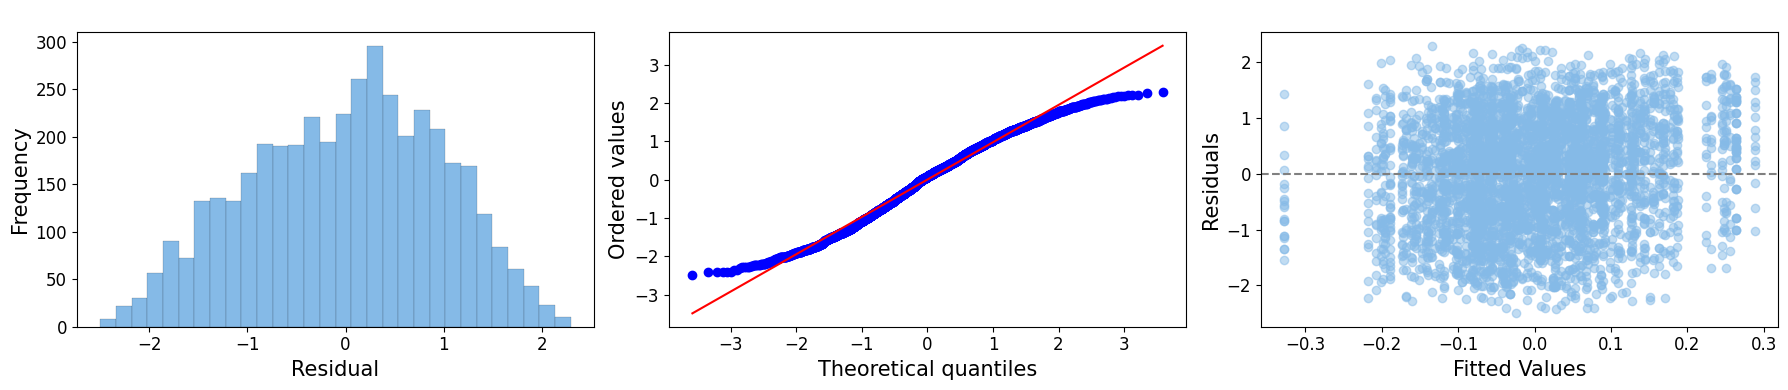


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅

------------------------------------------------------------------------------------------

--- Mixed Effects ANOVA ---
Formula: boxcox_gap_ai_price_scaled ~ C(gender, Treatment(reference="female"))
                           Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       boxcox_gap_ai_price_scaled
No. Observations:        4170          Method:                   REML                      
No. Groups:              236           Scale:                    0.9544                    
Min. group size:         8             Log-Likelihood:           -5893.6632                
Max. group size:         20            Converged:                Yes                       
Mean group size:         17.7             

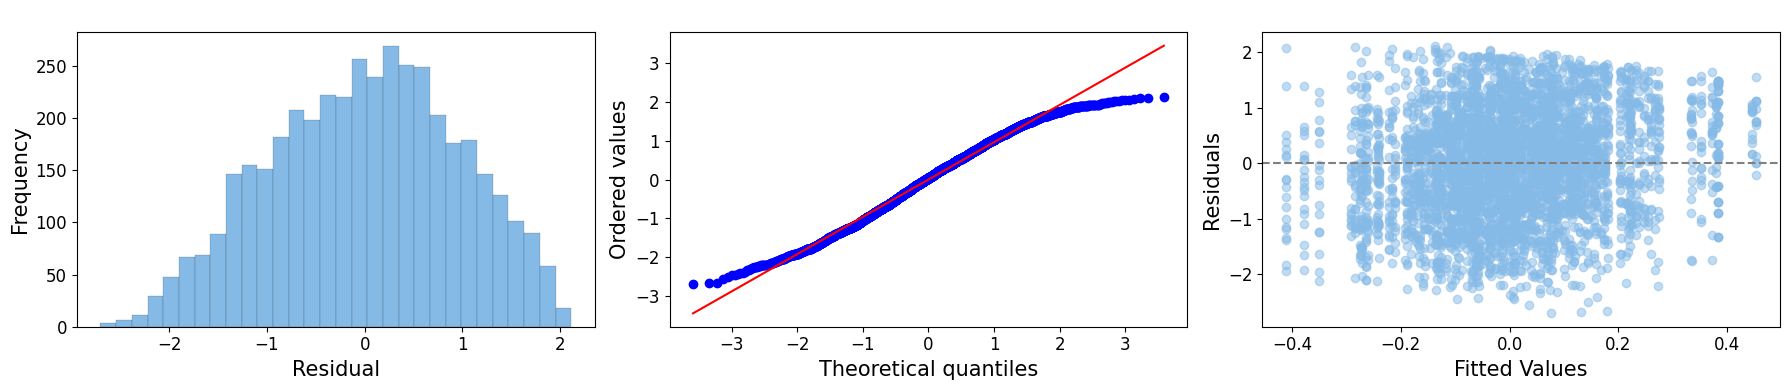


Assumption of normality fulfilled according to skewness and curtosis: ✅
Assumption of approximate normality fulfilled according to Shapiro-Wilk: ❌
Assumption of homogeneity fulfilled: ✅
Assumption of absence of multicollinearity: ✅


In [6]:
# block 2

data, houses, demographics, batch_info = als.load_valid_data(data_path)
phase_data = als.clean_data(data, demographics, houses, batch_info, phase='p1', transformation = 'boxcox')

# process datetime and hour
phase_data['datetime'] = pd.to_datetime(phase_data['SubmitTime'].str.replace(r' [A-Z]{3} ', ' ', regex=True))
phase_data['hour'] = phase_data['datetime'].dt.hour

# Compute total minutes since midnight
phase_data['minutes_since_midnight'] = (phase_data['datetime'].dt.hour * 60 + phase_data['datetime'].dt.minute)
phase_data['PublishingTime'] = phase_data['hour'] >= 8
phase_data['PublishingTime'] = phase_data['PublishingTime'].astype(int)

unique_users = phase_data.drop_duplicates(subset=['userID'])


# model 1: boxcox_gap_house_price_scaled
dependent = 'boxcox_gap_house_price_scaled'
save_plots = False

name = 'model-gender'
raw_covs = []
formula = f'{dependent} ~ C(gender, Treatment(reference="female"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)

# model 2: boxcox_gap_ai_price_scaled

dependent = 'boxcox_gap_ai_price_scaled'
save_plots = False

name = 'model-gender'
raw_covs = []
formula = f'{dependent} ~ C(gender, Treatment(reference="female"))'

##### Mixed Effects ANOVA ####
print('\n------------------------------------------------------------------------------------------\n')
model = als.perform_anova(phase_data, formula, random_effect='userID', use_random=True)
als.check_anova_assumptions(phase_data, dependent, 'attributedUserExplanationType', raw_covs, model, 'mixed-effects', name, save_plots)